In [ ]:
!pip install -q fairlearn shap

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
)
import shap

print("All imports OK")
print("pandas:", pd.__version__, "| sklearn ok | shap:", shap.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.1 MB/s eta 0:00:00
All imports OK
pandas: 2.2.2 | sklearn ok | shap: 0.52.0


In [ ]:
!wget -q -O diabetic_data.csv "https://raw.githubusercontent.com/14Richa/Patient-Readmission-Analysis/main/diabetic_data.csv"

df = pd.read_csv("diabetic_data.csv")
df = df.replace("?", np.nan)

print("Shape:", df.shape)
print("\nReadmitted value counts:")
print(df["readmitted"].value_counts())
print("\nRace value counts:")
print(df["race"].value_counts(dropna=False))
print("\nGender value counts:")
print(df["gender"].value_counts(dropna=False))
df.head()

Shape: (101766, 50)

Readmitted value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Race value counts:
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Gender value counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# One encounter per patient: keeping the first. ~30% of patient_nbr values
# repeat in the raw data, and letting the same patient land in both
# train and test would leak information across the split.
df = df.sort_values("encounter_id").drop_duplicates(subset="patient_nbr", keep="first")

# Drop encounters that ended in death. A deceased patient can't be
# readmitted, so these rows would corrupt the target.
EXPIRED_CODES = [11, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(EXPIRED_CODES)]

# Drop rows with missing/invalid sensitive attributes, since the fairness
# analysis later needs a clean group label to compare against.
df = df[df["race"].notna()]
df = df[df["gender"].isin(["Male", "Female"])]

# Binary target: 30-day readmission. CMS penalises hospitals on
# (the Hospital Readmissions Reduction Program),
# not "readmitted at all."
df["Target"] = (df["readmitted"] == "<30").astype(int)

print(f"Rows after cleaning: {len(df):,}")
print("\nTarget balance:")
print(df["Target"].value_counts(normalize=True).rename("proportion"))

race = df["race"].reset_index(drop=True)
gender = df["gender"].reset_index(drop=True)

print("\nRace distribution after cleaning:")
print(race.value_counts())

Rows after cleaning: 68,512

Target balance:
Target
0    0.910206
1    0.089794
Name: proportion, dtype: float64

Race distribution after cleaning:
race
Caucasian          52663
AfricanAmerican    12692
Hispanic            1506
Other               1160
Asian                491
Name: count, dtype: int64


In [ ]:
# Dropping ID columns, attributes with too much missed information:
# (weight is ~97% missing, medical_specialty ~49%, payer_code ~40%)
#
# Dropping the raw diagnosis codes (700+ distinct ICD-9 values, too sparse to
# be usefully),
# Dropping medication columns that are almost entirely "No" (add noise than signal).
drop_cols = [
    "encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty",
    "diag_1", "diag_2", "diag_3", "readmitted", "race", "gender",
    "examide", "citoglipton", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone", "acetohexamide",
    "troglitazone", "tolbutamide", "glipizide-metformin", "miglitol",
    "tolazamide",
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# These three columns are coded as integers in the raw data but are actually
# categories (admission type 1, 2, 3... are labels, )
# without this,the model would wrongly treat "discharge type 6" as more than "type 3."

categorical_id_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
for c in categorical_id_cols:
    df_model[c] = df_model[c].astype("category")

cat_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Target"]

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# XGBoost rejects "[", "]", "<" in feature names -- the age-band columns
# (e.g. "age_[70-80)") contain them, so adapting before modelling.
df_model.columns = (
    df_model.columns.str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace(",", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

X = df_model.drop(columns=["Target"])
y = df_model["Target"].reset_index(drop=True)
feature_names = X.columns

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nAny non-numeric columns left in X?", X.select_dtypes(exclude=[np.number, "bool"]).columns.tolist())
print("\nSample feature names:", list(feature_names[:10]))

X shape: (68512, 103)
y shape: (68512,)

Any non-numeric columns left in X? []

Sample feature names: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_10_20)', 'age_20_30)']


Train / Test Split

In [ ]:
# Cell 5

X_scaled = StandardScaler().fit_transform(X)

(
    X_train, X_test, y_train, y_test,
    race_train, race_test, gender_train, gender_test,
) = train_test_split(
    X_scaled, y, race, gender, test_size=0.2, random_state=42, stratify=y
)

sens_test_df = pd.DataFrame({
    "Race": race_test.reset_index(drop=True),
    "Gender": gender_test.reset_index(drop=True),
})

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain target balance:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nTest target balance:")
print(pd.Series(y_test).value_counts(normalize=True))
print("\nsens_test_df shape:", sens_test_df.shape, "| matches X_test rows?", len(sens_test_df) == X_test.shape[0])

Train shape: (54809, 103) | Test shape: (13703, 103)

Train target balance:
Target
0    0.910197
1    0.089803
Name: proportion, dtype: float64

Test target balance:
Target
0    0.910239
1    0.089761
Name: proportion, dtype: float64

sens_test_df shape: (13703, 2) | matches X_test rows? True


Training 3 models


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ),
}

trained_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[model_name] = {"y_pred": y_pred, "y_proba": y_proba}

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"  Accuracy: {acc:.3f} | AUROC: {auc:.3f}\n")

Training LogisticRegression...
  Accuracy: 0.668 | AUROC: 0.628

Training RandomForest...
  Accuracy: 0.716 | AUROC: 0.625

Training XGBoost...
  Accuracy: 0.720 | AUROC: 0.603



In [ ]:
def disparate_impact(y_true, y_pred, sensitive_features, privileged_value):
    frame = MetricFrame(metrics=selection_rate, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    sr = frame.by_group
    privileged_rate = sr.get(privileged_value, np.nan)
    unprivileged = sr.drop(privileged_value, errors="ignore")
    return (unprivileged / privileged_rate).to_dict()

mf_metrics = {"accuracy": accuracy_score, "selection_rate": selection_rate}
fairness_results = []

for model_name in models:
    y_pred = predictions[model_name]["y_pred"]
    row = {"model": model_name}

    for attr in ["Race", "Gender"]:
        sens = sens_test_df[attr]
        frame = MetricFrame(metrics=mf_metrics, y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        eo_diff = equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        privileged = "Caucasian" if attr == "Race" else "Male"
        di = disparate_impact(y_test, y_pred, sensitive_features=sens, privileged_value=privileged)

        print(f"\n[{model_name} | {attr}] DP diff: {dp_diff:.3f} | EO diff: {eo_diff:.3f}")
        print(frame.by_group)
        print(f"Disparate impact vs {privileged}: {di}")

        row[f"dp_diff_{attr}"] = dp_diff
        row[f"eo_diff_{attr}"] = eo_diff
        for group, val in di.items():
            row[f"di_{attr}_{group}"] = val

    fairness_results.append(row)

fairness_df = pd.DataFrame(fairness_results)
fairness_df


[LogisticRegression | Race] DP diff: 0.090 | EO diff: 0.425
                 accuracy  selection_rate
Race                                     
AfricanAmerican  0.717548        0.268830
Asian            0.742574        0.287129
Caucasian        0.653915        0.347032
Hispanic         0.686667        0.310000
Other            0.726531        0.257143
Disparate impact vs Caucasian: {'AfricanAmerican': 0.774656202994368, 'Asian': 0.8273850850296488, 'Hispanic': 0.8932905866302865, 'Other': 0.7409783667900993}

[LogisticRegression | Gender] DP diff: 0.035 | EO diff: 0.043
        accuracy  selection_rate
Gender                          
Female  0.655215        0.346421
Male    0.683103        0.310930
Disparate impact vs Male: {'Female': 1.1141467848216315}

[RandomForest | Race] DP diff: 0.096 | EO diff: 0.412
                 accuracy  selection_rate
Race                                     
AfricanAmerican  0.750401        0.226362
Asian            0.821782        0.188119
Caucasian 

,model,dp_diff_Race,eo_diff_Race,di_Race_AfricanAmerican,di_Race_Asian,di_Race_Hispanic,di_Race_Other,dp_diff_Gender,eo_diff_Gender,di_Gender_Female
0,LogisticRegression,0.089889,0.425000,0.774656,0.827385,0.893291,0.740978,0.035492,0.042697,1.114147
1,RandomForest,0.095851,0.412500,0.797136,0.662462,0.845162,0.689928,0.045132,0.078525,1.183410
2,XGBoost,0.063928,0.138091,0.838570,0.764839,0.858319,0.825788,0.030062,0.074548,1.122399


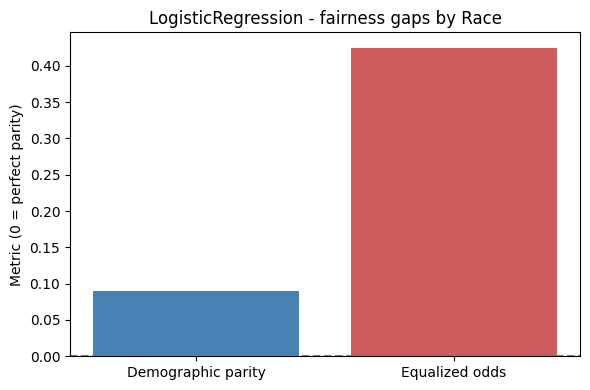

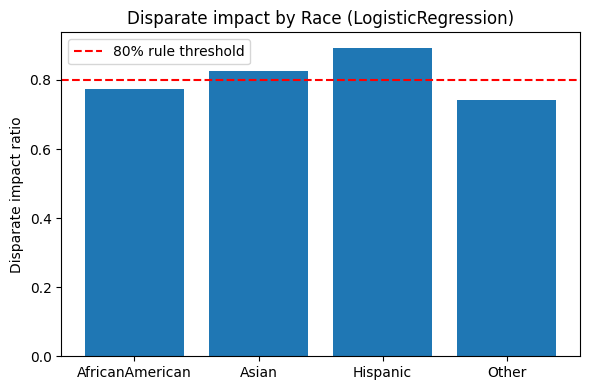

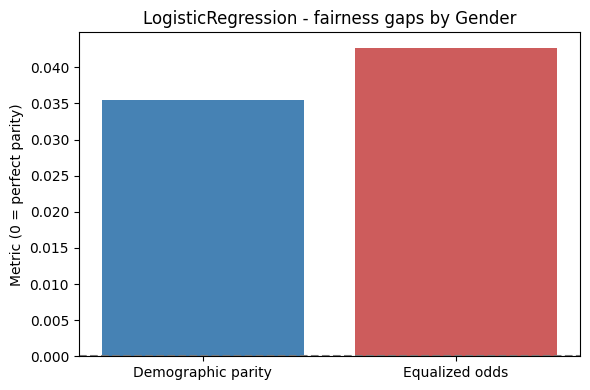

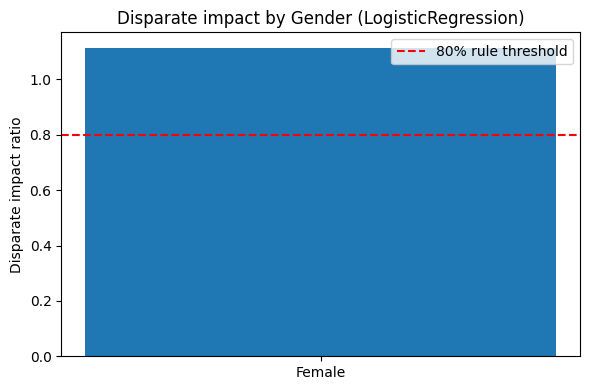

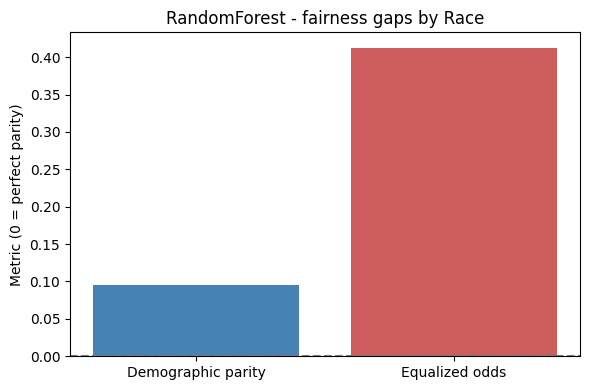

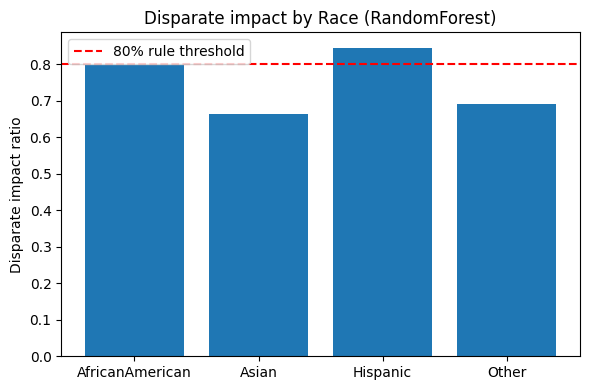

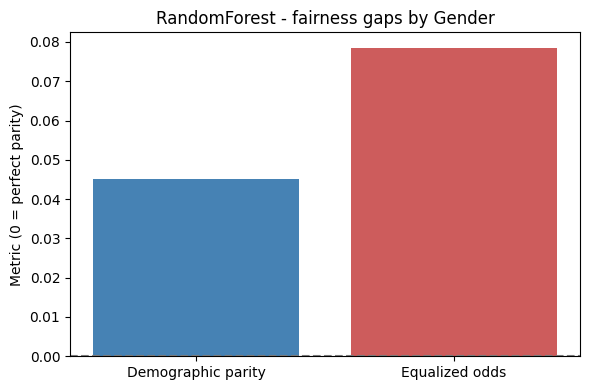

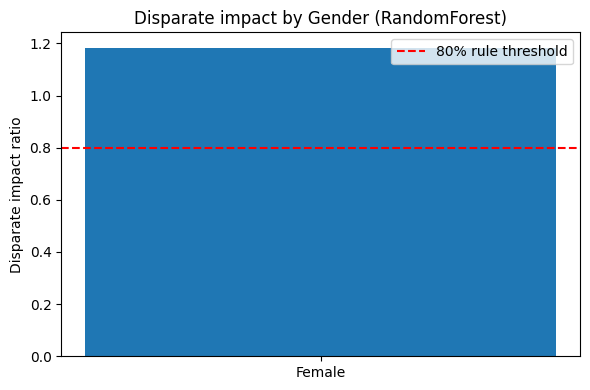

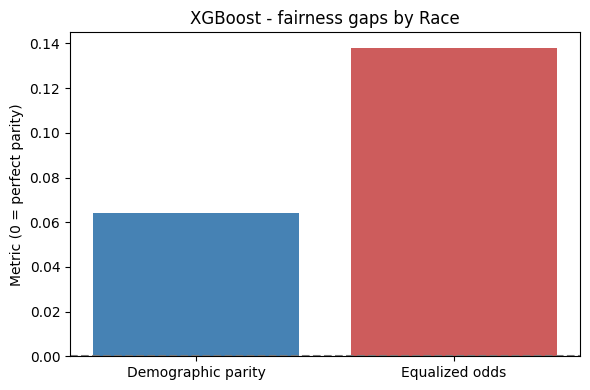

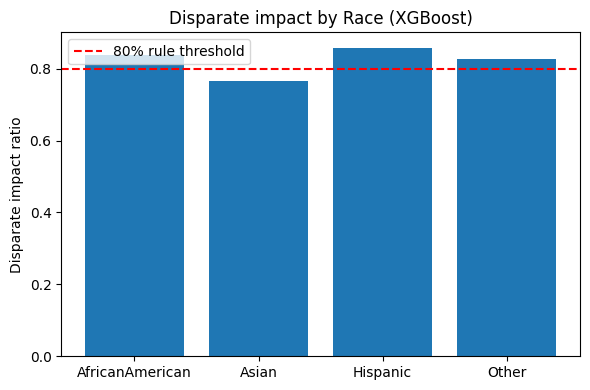

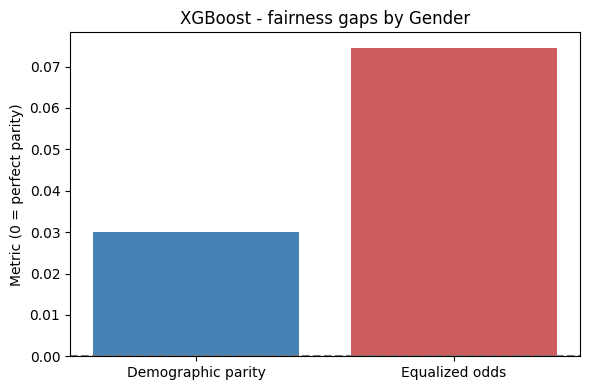

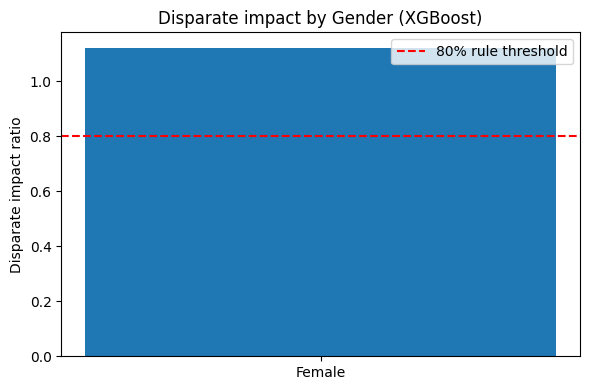

Saved 12 plots to outputs/plots/


In [ ]:
# Cell 8

import os
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

fairness_df.to_csv("outputs/tables/model_fairness_summary.csv", index=False)

for model_name in models:
    y_pred = predictions[model_name]["y_pred"]
    for attr in ["Race", "Gender"]:
        sens = sens_test_df[attr]
        dp_diff = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        eo_diff = equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        privileged = "Caucasian" if attr == "Race" else "Male"
        di = disparate_impact(y_test, y_pred, sensitive_features=sens, privileged_value=privileged)

        frame = MetricFrame(metrics=mf_metrics, y_true=y_test, y_pred=y_pred, sensitive_features=sens)
        frame.by_group.to_csv(f"outputs/tables/group_metrics_{model_name}_{attr}.csv")

        plt.figure(figsize=(6, 4))
        plt.bar(["Demographic parity", "Equalized odds"], [dp_diff, eo_diff], color=["steelblue", "indianred"])
        plt.axhline(0, color="gray", linestyle="--")
        plt.title(f"{model_name} - fairness gaps by {attr}")
        plt.ylabel("Metric (0 = perfect parity)")
        plt.tight_layout()
        plt.savefig(f"outputs/plots/fairness_gaps_{model_name}_{attr}.png")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.bar(list(di.keys()), list(di.values()))
        plt.axhline(0.8, color="red", linestyle="--", label="80% rule threshold")
        plt.title(f"Disparate impact by {attr} ({model_name})")
        plt.ylabel("Disparate impact ratio")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"outputs/plots/disparate_impact_{model_name}_{attr}.png")
        plt.show()

print("Saved", len(os.listdir("outputs/plots")), "plots to outputs/plots/")

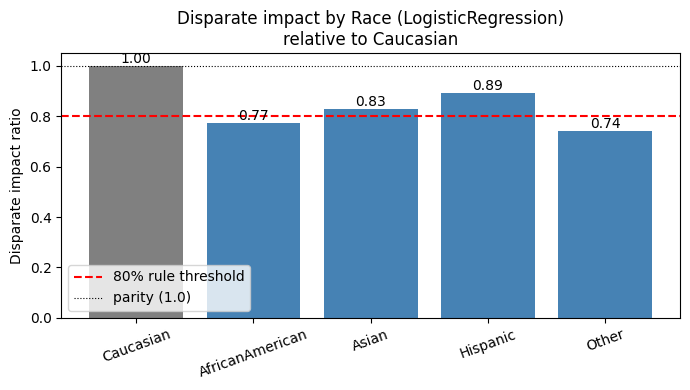

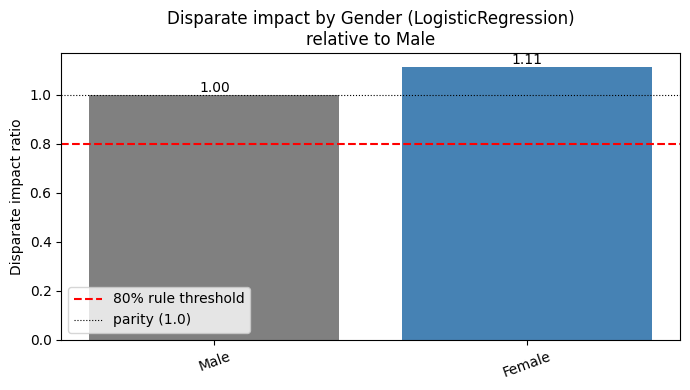

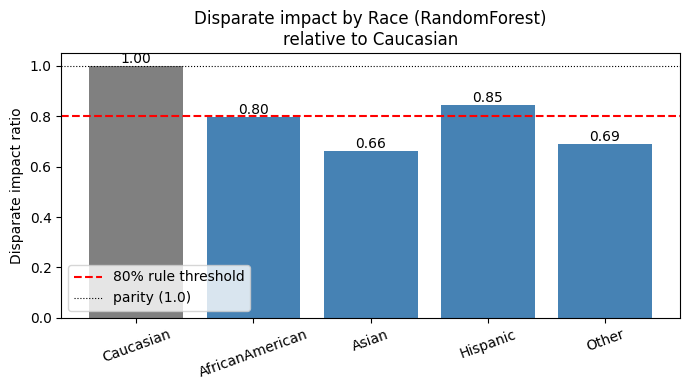

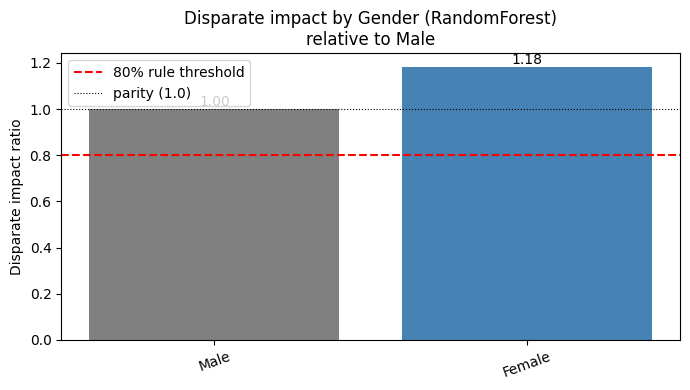

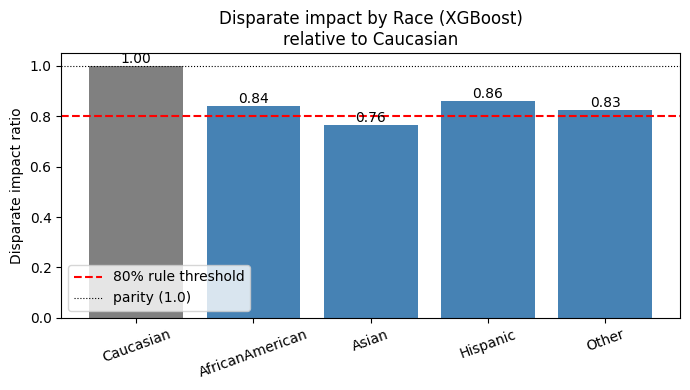

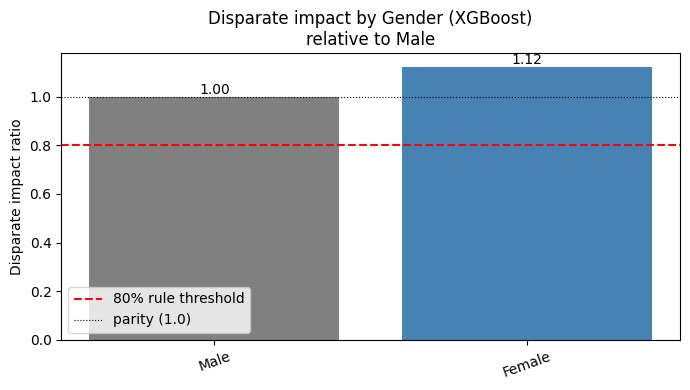

In [ ]:
# Cell 8b - polished disparate impact charts (Race and Gender)
for model_name in models:
    y_pred = predictions[model_name]["y_pred"]
    for attr in ["Race", "Gender"]:
        sens = sens_test_df[attr]
        privileged = "Caucasian" if attr == "Race" else "Male"
        di = disparate_impact(y_test, y_pred, sensitive_features=sens, privileged_value=privileged)

        labels = [privileged] + list(di.keys())
        values = [1.0] + list(di.values())  # privileged group is always 1.0 vs itself

        plt.figure(figsize=(7, 4))
        bars = plt.bar(labels, values, color=["gray"] + ["steelblue"] * len(di))
        plt.axhline(0.8, color="red", linestyle="--", label="80% rule threshold")
        plt.axhline(1.0, color="black", linestyle=":", linewidth=0.8, label="parity (1.0)")
        plt.bar_label(bars, fmt="%.2f")
        plt.title(f"Disparate impact by {attr} ({model_name})\nrelative to {privileged}")
        plt.ylabel("Disparate impact ratio")
        plt.legend()
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(f"outputs/plots/disparate_impact_{model_name}_{attr}_v2.png")
        plt.show()

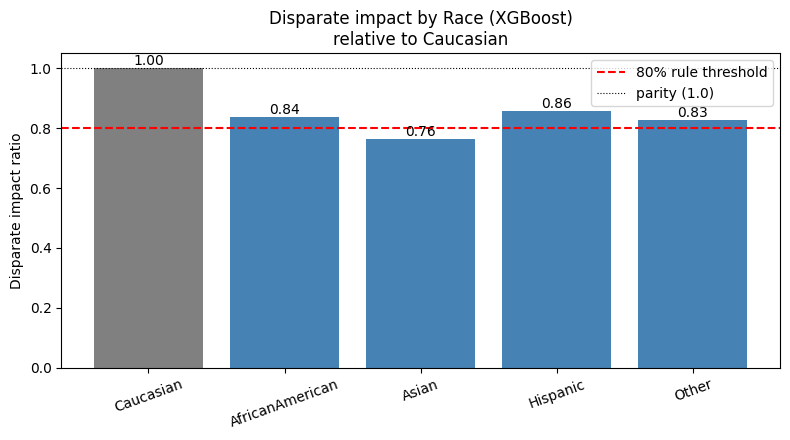

In [ ]:
y_pred = predictions["XGBoost"]["y_pred"]
sens = sens_test_df["Race"]
di = disparate_impact(y_test, y_pred, sensitive_features=sens, privileged_value="Caucasian")

labels = ["Caucasian"] + list(di.keys())
values = [1.0] + list(di.values())

plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, values, color=["gray"] + ["steelblue"] * len(di))
plt.axhline(0.8, color="red", linestyle="--", label="80% rule threshold")
plt.axhline(1.0, color="black", linestyle=":", linewidth=0.8, label="parity (1.0)")
plt.bar_label(bars, fmt="%.2f")
plt.title("Disparate impact by Race (XGBoost)\nrelative to Caucasian")
plt.ylabel("Disparate impact ratio")
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/plots/disparate_impact_XGBoost_Race_v2.png")
plt.show()

The proxy-bias check

In [ ]:
proxy_check = df.copy()
proxy_check["utilization_proxy"] = (
    proxy_check["number_outpatient"] + proxy_check["number_emergency"] + proxy_check["number_inpatient"]
)
proxy_check["severity_proxy"] = (
    proxy_check["number_diagnoses"] + proxy_check["time_in_hospital"] + proxy_check["num_procedures"]
)

proxy_by_race = proxy_check.groupby("race")[["utilization_proxy", "severity_proxy", "Target"]].mean()
proxy_by_race["utilization_per_severity"] = proxy_by_race["utilization_proxy"] / proxy_by_race["severity_proxy"]
proxy_by_race.to_csv("outputs/tables/proxy_bias_check_by_race.csv")

print(proxy_by_race)



                 utilization_proxy  severity_proxy    Target  \
race                                                           
AfricanAmerican           0.445556       12.508273  0.086117   
Asian                     0.380855       11.820774  0.083503   
Caucasian                 0.602586       13.110552  0.091449   
Hispanic                  0.563745       11.828021  0.081009   
Other                     0.416379       12.768103  0.068966   

                 utilization_per_severity  
race                                       
AfricanAmerican                  0.035621  
Asian                            0.032219  
Caucasian                        0.045962  
Hispanic                         0.047662  
Other                            0.032611  


                 utilization_proxy  severity_proxy    Target  \
race                                                           
AfricanAmerican           0.445556       12.508273  0.086117   
Asian                     0.380855       11.820774  0.083503   
Caucasian                 0.602586       13.110552  0.091449   
Hispanic                  0.563745       11.828021  0.081009   
Other                     0.416379       12.768103  0.068966   

                 utilization_per_severity  
race                                       
AfricanAmerican                  0.035621  
Asian                            0.032219  
Caucasian                        0.045962  
Hispanic                         0.047662  
Other                            0.032611  


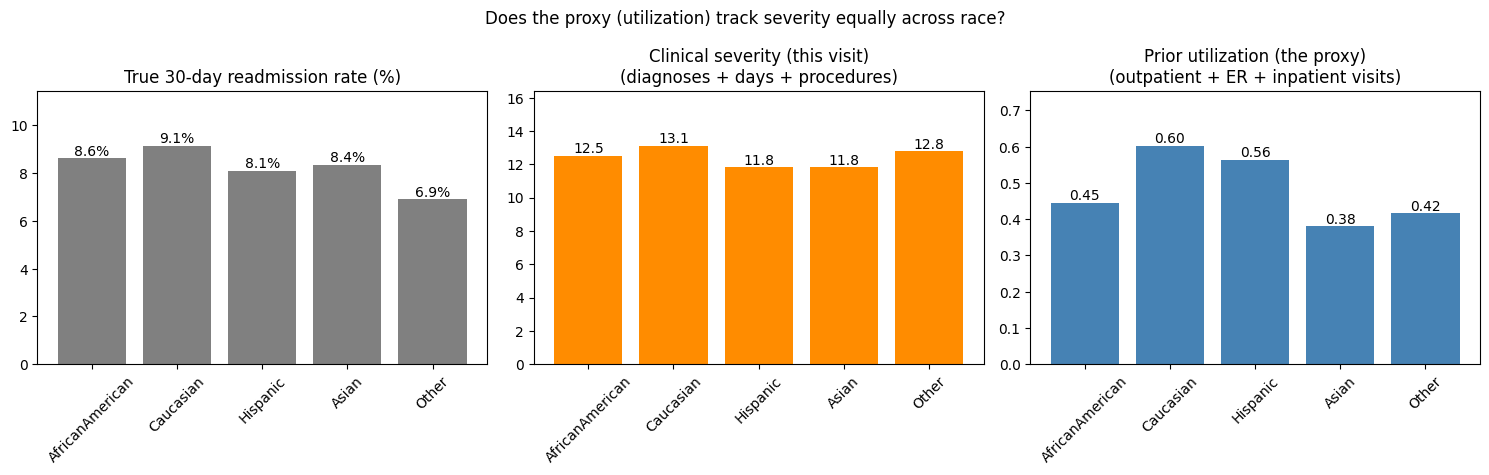

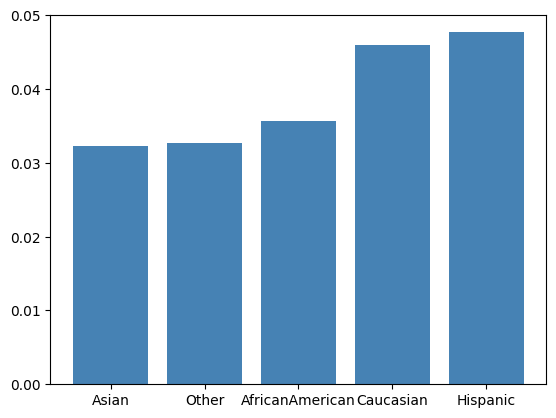

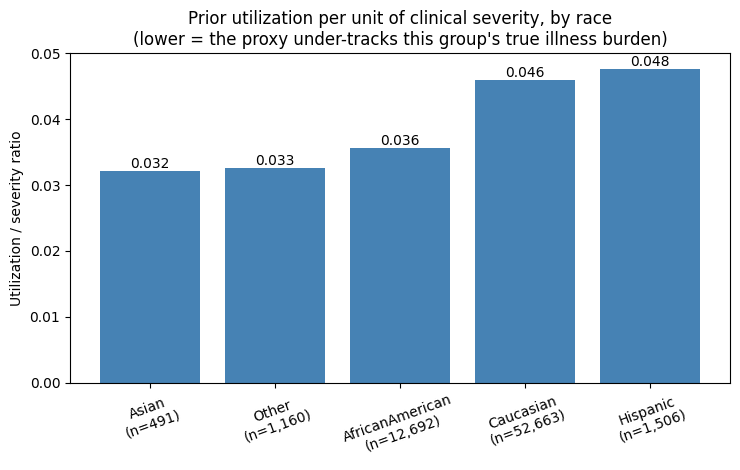

In [ ]:

proxy_check = df.copy()
proxy_check["utilization_proxy"] = (
    proxy_check["number_outpatient"] + proxy_check["number_emergency"] + proxy_check["number_inpatient"]
)
proxy_check["severity_proxy"] = (
    proxy_check["number_diagnoses"] + proxy_check["time_in_hospital"] + proxy_check["num_procedures"]
)

proxy_by_race = proxy_check.groupby("race")[["utilization_proxy", "severity_proxy", "Target"]].mean()
proxy_by_race["utilization_per_severity"] = proxy_by_race["utilization_proxy"] / proxy_by_race["severity_proxy"]
proxy_by_race.to_csv("outputs/tables/proxy_bias_check_by_race.csv")
print(proxy_by_race)

order = ["AfricanAmerican", "Caucasian", "Hispanic", "Asian", "Other"]
pbr = proxy_by_race.loc[order]

# --- 3-panel labeled chart ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

b0 = axes[0].bar(pbr.index, pbr["Target"] * 100, color="gray")
axes[0].set_title("True 30-day readmission rate (%)")
axes[0].bar_label(b0, fmt="%.1f%%")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, max(pbr["Target"] * 100) * 1.25)

b1 = axes[1].bar(pbr.index, pbr["severity_proxy"], color="darkorange")
axes[1].set_title("Clinical severity (this visit)\n(diagnoses + days + procedures)")
axes[1].bar_label(b1, fmt="%.1f")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, max(pbr["severity_proxy"]) * 1.25)

b2 = axes[2].bar(pbr.index, pbr["utilization_proxy"], color="steelblue")
axes[2].set_title("Prior utilization (the proxy)\n(outpatient + ER + inpatient visits)")
axes[2].bar_label(b2, fmt="%.2f")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, max(pbr["utilization_proxy"]) * 1.25)

plt.suptitle("Does the proxy (utilization) track severity equally across race?")
plt.tight_layout()
plt.savefig("outputs/plots/proxy_bias_check_by_race_v2.png", dpi=130)
plt.show()

# --- punchline ratio chart, sorted, with sample sizes ---
ratio = pbr["utilization_per_severity"].sort_values()
group_sizes = df["race"].value_counts()
bars = plt.bar(ratio.index, ratio.values, color="steelblue")
plt.figure(figsize=(7.5, 4.8))
bars = plt.bar(ratio.index, ratio.values, color="steelblue")
plt.bar_label(bars, fmt="%.3f")
labels_with_n = [f"{g}\n(n={group_sizes[g]:,})" for g in ratio.index]
plt.xticks(range(len(ratio)), labels_with_n, rotation=20)
plt.title("Prior utilization per unit of clinical severity, by race\n(lower = the proxy under-tracks this group's true illness burden)")
plt.ylabel("Utilization / severity ratio")
plt.tight_layout()
plt.savefig("outputs/plots/proxy_bias_ratio_by_race.png", dpi=130)
plt.show()

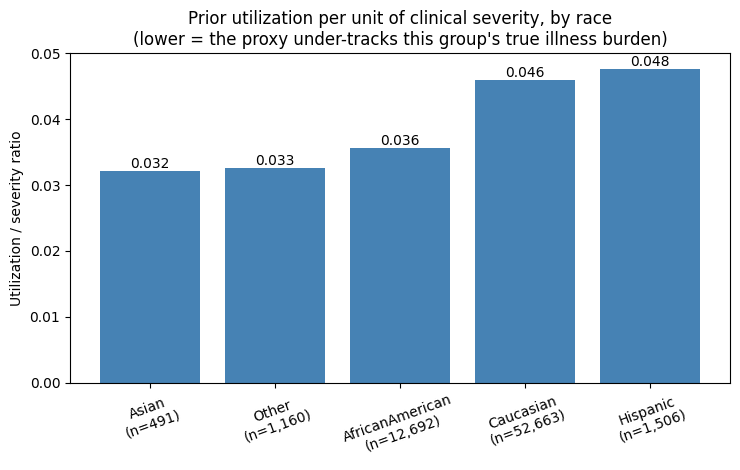

In [ ]:
# Utilisation per unit of severity, the actual mismatch number
plt.figure(figsize=(7.5, 4.8))
ratio = pbr["utilization_per_severity"].sort_values()
group_sizes = df["race"].value_counts()
colors = ["steelblue"] * len(ratio)
bars = plt.bar(ratio.index, ratio.values, color=colors)
plt.bar_label(bars, fmt="%.3f")
labels_with_n = [f"{g}\n(n={group_sizes[g]:,})" for g in ratio.index]
plt.xticks(range(len(ratio)), labels_with_n, rotation=20)
plt.title("Prior utilization per unit of clinical severity, by race\n(lower = the proxy under-tracks this group's true illness burden)")
plt.ylabel("Utilization / severity ratio")
plt.tight_layout()
plt.savefig("outputs/plots/proxy_bias_ratio_by_race.png", dpi=130)
plt.show()

SHAP, global feature importance

In [ ]:
os.makedirs("outputs/explainability", exist_ok=True)

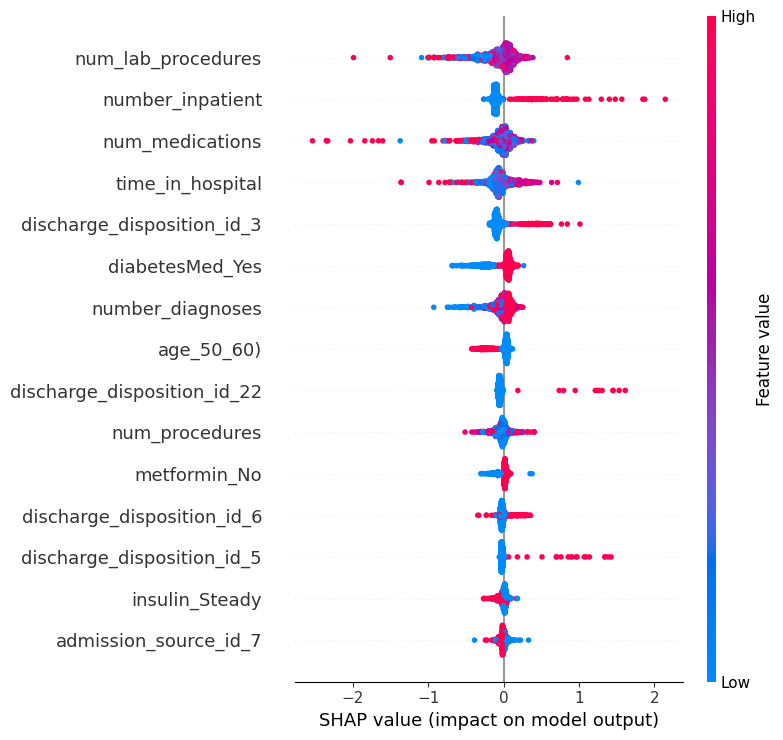

                         feature  mean_abs_shap
1             num_lab_procedures       0.159075
6               number_inpatient       0.150340
3                num_medications       0.131097
0               time_in_hospital       0.125333
25    discharge_disposition_id_3       0.121372
102              diabetesMed_Yes       0.116462
7               number_diagnoses       0.091137
12                    age_50_60)       0.072521
40   discharge_disposition_id_22       0.062321
2                 num_procedures       0.060976
66                  metformin_No       0.040869
28    discharge_disposition_id_6       0.040322
27    discharge_disposition_id_5       0.036294
96                insulin_Steady       0.032000
51         admission_source_id_7       0.031735


In [ ]:
xgb_model = trained_models["XGBoost"]
X_test_df = pd.DataFrame(X_test, columns=feature_names)

sample_idx = np.random.RandomState(42).choice(len(X_test_df), size=min(1000, len(X_test_df)), replace=False)
X_shap_sample = X_test_df.iloc[sample_idx].reset_index(drop=True)
race_shap_sample = sens_test_df["Race"].iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap_sample)

shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=15)
plt.tight_layout()
plt.savefig("outputs/explainability/shap_summary_global.png", dpi=130)
plt.show()

mean_abs_shap = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
mean_abs_shap.to_csv("outputs/tables/shap_global_importance.csv", index=False)
print(mean_abs_shap.head(15))

SHAP, African American vs. Caucasian


AfricanAmerican: n = 186


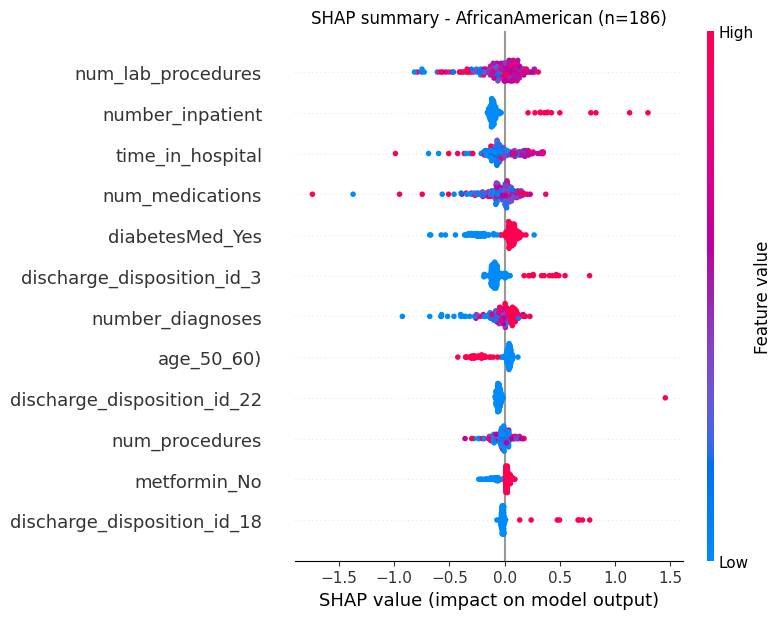


Caucasian: n = 776


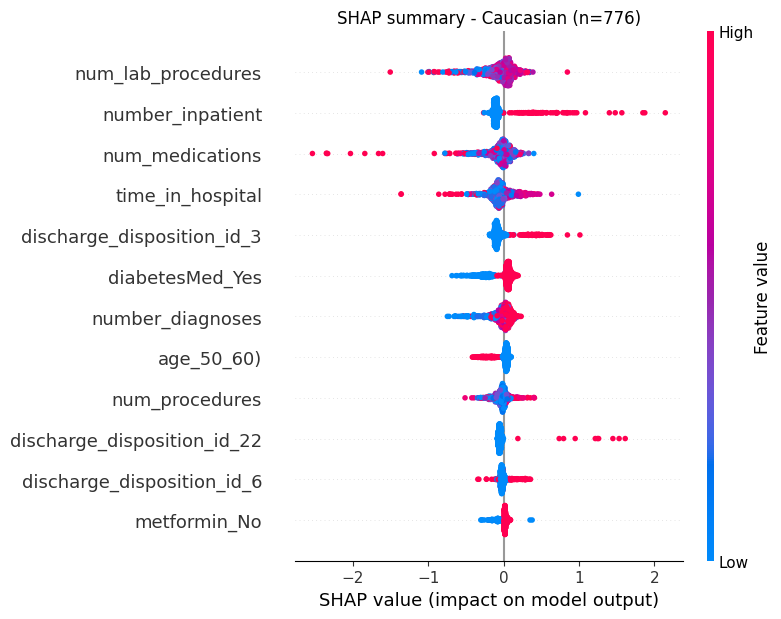

In [ ]:
for grp in ["AfricanAmerican", "Caucasian"]:
    mask = (race_shap_sample == grp).values
    n = mask.sum()
    print(f"\n{grp}: n = {n}")
    if n < 20:
        print("  Skipping, sample too small for a stable plot.")
        continue
    shap.summary_plot(shap_values[mask], X_shap_sample[mask], show=False, max_display=12)
    plt.title(f"SHAP summary - {grp} (n={n})")
    plt.tight_layout()
    plt.savefig(f"outputs/explainability/shap_summary_{grp}.png", dpi=130)
    plt.show()

Does model choice change the outcome for African American patients?

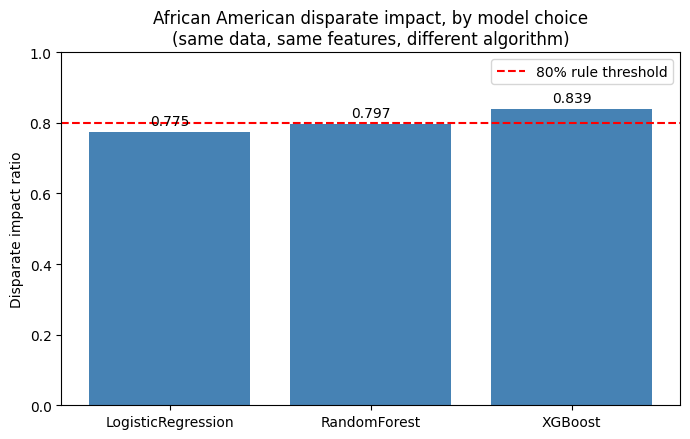

In [28]:
di_by_model = {
    "LogisticRegression": 0.774656,
    "RandomForest": 0.797136,
    "XGBoost": 0.838570,
}
plt.figure(figsize=(7, 4.5))
bars = plt.bar(di_by_model.keys(), di_by_model.values(), color="steelblue")
plt.axhline(0.8, color="red", linestyle="--", label="80% rule threshold")
plt.bar_label(bars, fmt="%.3f", padding=3)
plt.ylim(0, 1.0)
plt.title("African American disparate impact, by model choice\n(same data, same features, different algorithm)")
plt.ylabel("Disparate impact ratio")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("outputs/plots/di_by_model_african_american.png", dpi=130)
plt.show()

LIME analysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Matched pair, both near median test-set severity:
               race  severity_proxy  utilization_proxy  Target
82  AfricanAmerican              12                  0       0
12        Caucasian              12                  2       0

LIME explanation - AfricanAmerican (severity=12, utilization=0):
  discharge_disposition_id_3 <= -0.38: -0.090
  discharge_disposition_id_22 <= -0.14: -0.082
  admission_source_id_22 <= -0.01: +0.062
  pioglitazone_Up <= -0.05: -0.055
  repaglinide_Up <= -0.03: +0.055
  admission_source_id_3 <= -0.04: -0.053
  discharge_disposition_id_7 <= -0.08: -0.049
  admission_source_id_2 <= -0.11: +0.042
  discharge_disposition_id_8 <= -0.03: +0.038
  discharge_disposition_id_17 <= -0.01: +0.018


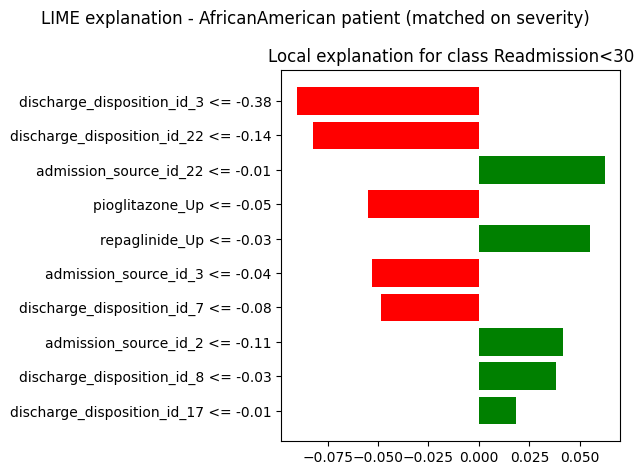


LIME explanation - Caucasian (severity=12, utilization=2):
  nateglinide_Up <= -0.02: -0.153
  chlorpropamide_Up <= -0.01: -0.110
  discharge_disposition_id_22 <= -0.14: -0.074
  discharge_disposition_id_15 <= -0.02: -0.074
  discharge_disposition_id_3 <= -0.38: -0.072
  discharge_disposition_id_23 <= -0.06: +0.050
  discharge_disposition_id_7 <= -0.08: -0.050
  discharge_disposition_id_28 <= -0.04: +0.017
  admission_source_id_10 <= -0.01: +0.016
  discharge_disposition_id_10 <= -0.01: +0.014


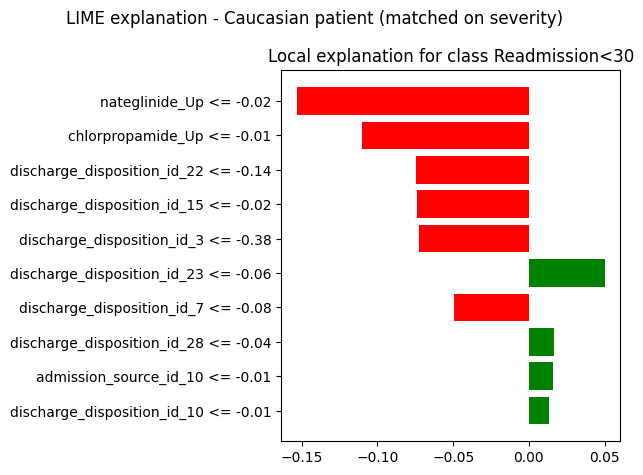

In [29]:
!pip install -q lime
from lime.lime_tabular import LimeTabularExplainer

# Recover original row info for the test set (train_test_split doesn't keep
# patient-level detail, so we reproduce the same split on a plain index array)
idx_train, idx_test = train_test_split(
    np.arange(len(X)), test_size=0.2, random_state=42, stratify=y
)
df_test_lookup = df.reset_index(drop=True).iloc[idx_test].reset_index(drop=True)
df_test_lookup["severity_proxy"] = (
    df_test_lookup["number_diagnoses"] + df_test_lookup["time_in_hospital"] + df_test_lookup["num_procedures"]
)
df_test_lookup["utilization_proxy"] = (
    df_test_lookup["number_outpatient"] + df_test_lookup["number_emergency"] + df_test_lookup["number_inpatient"]
)

median_severity = df_test_lookup["severity_proxy"].median()

aa_pool = df_test_lookup[df_test_lookup["race"] == "AfricanAmerican"].copy()
ca_pool = df_test_lookup[df_test_lookup["race"] == "Caucasian"].copy()
aa_match = aa_pool.iloc[(aa_pool["severity_proxy"] - median_severity).abs().argsort()[:1]]
ca_match = ca_pool.iloc[(ca_pool["severity_proxy"] - median_severity).abs().argsort()[:1]]

aa_idx, ca_idx = aa_match.index[0], ca_match.index[0]
print("Matched pair, both near median test-set severity:")
print(df_test_lookup.loc[[aa_idx, ca_idx], ["race", "severity_proxy", "utilization_proxy", "Target"]])

lime_explainer = LimeTabularExplainer(
    X_train, feature_names=list(feature_names),
    class_names=["No readmission<30", "Readmission<30"], mode="classification"
)

for label, idx in [("AfricanAmerican", aa_idx), ("Caucasian", ca_idx)]:
    exp = lime_explainer.explain_instance(X_test[idx], xgb_model.predict_proba, num_features=10)
    print(f"\nLIME explanation - {label} (severity={df_test_lookup.loc[idx,'severity_proxy']}, "
          f"utilization={df_test_lookup.loc[idx,'utilization_proxy']}):")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:+.3f}")
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME explanation - {label} patient (matched on severity)")
    plt.tight_layout()
    plt.savefig(f"outputs/explainability/lime_{label}.png", dpi=130)
    plt.show()

Not great results, trying again

In [30]:
target_severity = 20  # a more clinically severe patient, where flagging decisions matter most
aa_match2 = aa_pool.iloc[(aa_pool["severity_proxy"] - target_severity).abs().argsort()[:1]]
ca_match2 = ca_pool.iloc[(ca_pool["severity_proxy"] - target_severity).abs().argsort()[:1]]
aa_idx2, ca_idx2 = aa_match2.index[0], ca_match2.index[0]

print(df_test_lookup.loc[[aa_idx2, ca_idx2], ["race", "severity_proxy", "utilization_proxy", "Target"]])

for label, idx in [("AfricanAmerican_v2", aa_idx2), ("Caucasian_v2", ca_idx2)]:
    exp = lime_explainer.explain_instance(X_test[idx], xgb_model.predict_proba, num_features=10)
    print(f"\nLIME explanation - {label} (severity={df_test_lookup.loc[idx,'severity_proxy']}, "
          f"utilization={df_test_lookup.loc[idx,'utilization_proxy']}):")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:+.3f}")

                 race  severity_proxy  utilization_proxy  Target
4914  AfricanAmerican              20                  0       0
547         Caucasian              20                  0       0

LIME explanation - AfricanAmerican_v2 (severity=20, utilization=0):
  admission_type_id_4 <= -0.01: -0.170
  discharge_disposition_id_22 <= -0.14: -0.095
  discharge_disposition_id_3 <= -0.38: -0.090
  admission_source_id_8 <= -0.01: -0.084
  discharge_disposition_id_7 <= -0.08: -0.055
  age_80_90) <= -0.44: -0.046
  admission_source_id_9 <= -0.02: +0.042
  discharge_disposition_id_9 <= -0.01: +0.042
  discharge_disposition_id_15 <= -0.02: -0.031
  discharge_disposition_id_24 <= -0.02: +0.014

LIME explanation - Caucasian_v2 (severity=20, utilization=0):
  discharge_disposition_id_15 <= -0.02: -0.173
  discharge_disposition_id_22 <= -0.14: -0.111
  discharge_disposition_id_3 <= -0.38: -0.082
  discharge_disposition_id_7 <= -0.08: -0.072
  -0.60 < num_lab_procedures <= 0.06: +0.046
  age_80_90)

In [31]:
# Does the proxy feature show up locally when it's actually present, not zero?
high_util_patient = df_test_lookup.loc[df_test_lookup["utilization_proxy"].idxmax()]
idx3 = high_util_patient.name
print(df_test_lookup.loc[[idx3], ["race", "severity_proxy", "utilization_proxy", "Target"]])

exp = lime_explainer.explain_instance(X_test[idx3], xgb_model.predict_proba, num_features=10)
print(f"\nLIME explanation - highest-utilization patient in test set "
      f"(race={high_util_patient['race']}, utilization={high_util_patient['utilization_proxy']}):")
for feat, weight in exp.as_list():
    print(f"  {feat}: {weight:+.3f}")

           race  severity_proxy  utilization_proxy  Target
2448  Caucasian              12                 42       0

LIME explanation - highest-utilization patient in test set (race=Caucasian, utilization=42):
  discharge_disposition_id_15 <= -0.02: -0.118
  repaglinide_Up <= -0.03: -0.111
  discharge_disposition_id_22 <= -0.14: -0.106
  discharge_disposition_id_3 <= -0.38: -0.080
  discharge_disposition_id_7 <= -0.08: -0.052
  rosiglitazone_Up <= -0.04: +0.046
  age_80_90) > -0.44: +0.045
  admission_source_id_5 <= -0.09: +0.040
  discharge_disposition_id_5 <= -0.11: +0.040
  acarbose_Up <= -0.01: +0.019
